# H1N1 Vaccine Prediction — Logistic Regression: Model Training & Experimentation

**Goal:** predict `h1n1_vaccine` (binary, imbalanced) starting from the cleaned
train/test data exported at the end of `02_Data_cleaning.ipynb`.

**Optimization metric:** F1-score (positive class = 1), since the target is imbalanced.

**Model:** Logistic Regression only. We compare configurations along four axes:

1. **Scaling** — none vs `StandardScaler` vs `MinMaxScaler`
2. **Class imbalance handling** — default vs `class_weight="balanced"`
3. **Feature selection** — all features vs top-K "important" features
4. **Feature engineering** — with vs without polynomial/interaction features

Every configuration is scored with `classification_eval()` from `useful_func.py`,
which runs `StratifiedKFold` cross-validation and reports mean/std train & valid
accuracy, precision, recall, and F1. All runs accumulate into one results table
so we can rank every experiment at the end and pick a winner, then confirm it on
the held-out test set.

## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (f1_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, precision_recall_curve)

# your helper — runs StratifiedKFold CV and appends a row of metrics
from useful_func import classification_eval

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Load the cleaned data

These four files were written at the end of `02_Data_cleaning.ipynb`. Adjust the
path if you're running this in Colab (e.g. `/content/X_train.csv`).

In [ ]:
X_train = pd.read_csv("X_train.csv", index_col=0)
X_test  = pd.read_csv("X_test.csv", index_col=0)
y_train = pd.read_csv("y_train.csv", index_col=0).squeeze()
y_test  = pd.read_csv("y_test.csv", index_col=0).squeeze()

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("y_train:", y_train.shape, " y_test:", y_test.shape)
X_train.head()

X_train: (20030, 50)  X_test: (6677, 50)
y_train: (20030,)  y_test: (6677,)


,h1n1_worry,h1n1_awareness,antiviral_medication,contact_avoidance,bought_face_mask,wash_hands_frequently,avoid_large_gatherings,reduced_outside_home_cont,avoid_touch_face,dr_recc_h1n1_vacc,dr_recc_seasonal_vacc,chronic_medic_condition,cont_child_undr_6_mnths,is_health_worker,has_health_insur,is_h1n1_vacc_effective,is_h1n1_risky,sick_from_h1n1_vacc,is_seas_vacc_effective,is_seas_risky,sick_from_seas_vacc,age_bracket,qualification,race,sex,income_level,marital_status,housing_status,employment,census_msa,no_of_adults,no_of_children,missingindicator_has_health_insur,missingindicator_income_level,missingindicator_dr_recc_h1n1_vacc,missingindicator_dr_recc_seasonal_vacc,missingindicator_housing_status,missingindicator_employment,missingindicator_marital_status,missingindicator_qualification,"census_msa_MSA, Principle City",census_msa_Non-MSA,employment_Not in Labor Force,employment_Unemployed,housing_status_Rent,marital_status_Not Married,sex_Male,race_Hispanic,race_Other or Multiple,race_White
11075,2.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,2.0,2.0,4.0,2.0,4.0,1.0,2.0,White,Female,1.0,Married,Own,Employed,"MSA, Not Principle City",1.0,2.0,0.0,False,False,False,False,False,False,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
7807,3.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,2.0,5.0,4.0,2.0,4.0,1.0,3.0,White,Male,1.0,Not Married,Own,Employed,"MSA, Principle City",1.0,0.0,1.0,False,False,False,False,False,False,False,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
3014,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,1.0,1.0,5.0,1.0,1.0,4.0,1.0,White,Female,1.0,Married,Own,Employed,Non-MSA,1.0,0.0,0.0,False,False,False,False,False,False,False,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1671,2.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,3.0,5.0,4.0,4.0,5.0,4.0,0.0,1.0,White,Female,1.0,Married,Rent,Employed,Non-MSA,0.0,0.0,1.0,False,False,False,False,False,False,False,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
16691,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,5.0,2.0,4.0,5.0,2.0,4.0,4.0,3.0,White,Male,2.0,Married,Own,Employed,"MSA, Not Principle City",1.0,0.0,1.0,False,False,False,False,False,False,False,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


### 2.1 Drop raw nominal columns

In the cleaning notebook, one-hot encoded columns were **added** alongside the
original nominal columns (`census_msa`, `employment`, `housing_status`,
`marital_status`, `sex`, `race`) rather than replacing them. Logistic Regression
needs numeric input, so drop the raw string columns and keep the encoded ones.

In [ ]:
raw_nominal_cols = ["census_msa", "employment", "housing_status",
                     "marital_status", "sex", "race"]

X_train = X_train.drop(columns=raw_nominal_cols)
X_test = X_test.drop(columns=raw_nominal_cols)

# sanity check — nothing non-numeric should remain
object_cols = X_train.select_dtypes(include="object").columns.tolist()
print("Remaining object columns (should be empty):", object_cols)
print(X_train.dtypes.value_counts())

Remaining object columns (should be empty): []
float64    37
bool        7
Name: count, dtype: int64


### 2.2 Confirm class imbalance

h1n1_vaccine
0    0.787569
1    0.212431
Name: proportion, dtype: float64


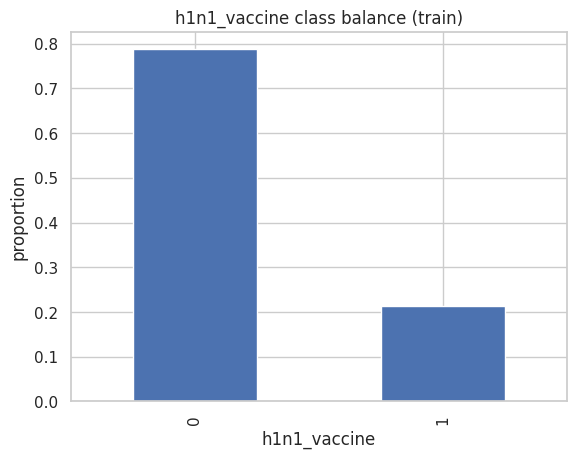

In [ ]:
print(y_train.value_counts(normalize=True))

y_train.value_counts(normalize=True).plot(
    kind="bar", title="h1n1_vaccine class balance (train)"
)
plt.xlabel("h1n1_vaccine")
plt.ylabel("proportion")
plt.show()

## 3. Experiment tracking

`classification_eval(method, model, X, y, fold=5)` appends one row per call to a
shared results table (it keeps accumulating even without passing `result_df`
explicitly, since the default lives at module level in `useful_func.py`). We just
keep calling it with a descriptive `method` name for each configuration and
capture the returned table.

In [ ]:
results = None  # will hold the running table after the first call

## 4. Baseline — raw features, no scaling, default class weights

In [ ]:
results = classification_eval(
    "baseline_raw",
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    X_train, y_train, fold=5
)
results

,method,mean_train_acc,mean_valid_acc,std_train_acc,std_valid_acc,mean_train_precision,mean_valid_precision,std_train_precision,std_valid_precision,mean_train_recall,mean_valid_recall,std_train_recall,std_valid_recall,mean_train_f1,mean_valid_f1,std_train_f1,std_valid_f1
0,baseline_raw,0.85352,0.851922,0.000804,0.002173,0.72962,0.72332,0.001571,0.009208,0.493243,0.490952,0.005216,0.016221,0.588571,0.58468,0.00382,0.010713


## 5. Scaling experiments

Logistic Regression is scale-sensitive (it's solved by gradient-based
optimizers and regularized), so scaling can change both convergence and the
regularization trade-off across features.

In [ ]:
scaler_std = StandardScaler()
X_train_std = pd.DataFrame(
    scaler_std.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)

results = classification_eval(
    "standard_scaled",
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    X_train_std, y_train, fold=5
)
results.tail(3)

,method,mean_train_acc,mean_valid_acc,std_train_acc,std_valid_acc,mean_train_precision,mean_valid_precision,std_train_precision,std_valid_precision,mean_train_recall,mean_valid_recall,std_train_recall,std_valid_recall,mean_train_f1,mean_valid_f1,std_train_f1,std_valid_f1
0,baseline_raw,0.853520,0.851922,0.000804,0.002173,0.729620,0.723320,0.001571,0.009208,0.493243,0.490952,0.005216,0.016221,0.588571,0.584680,0.003820,0.010713
1,standard_scaled,0.853532,0.851672,0.000819,0.002513,0.729203,0.722153,0.001443,0.008952,0.493948,0.490717,0.005111,0.016578,0.588938,0.584151,0.003806,0.011602


In [ ]:
scaler_mm = MinMaxScaler()
X_train_mm = pd.DataFrame(
    scaler_mm.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)

results = classification_eval(
    "minmax_scaled",
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    X_train_mm, y_train, fold=5
)
results.tail(3)

,method,mean_train_acc,mean_valid_acc,std_train_acc,std_valid_acc,mean_train_precision,mean_valid_precision,std_train_precision,std_valid_precision,mean_train_recall,mean_valid_recall,std_train_recall,std_valid_recall,mean_train_f1,mean_valid_f1,std_train_f1,std_valid_f1
0,baseline_raw,0.853520,0.851922,0.000804,0.002173,0.729620,0.723320,0.001571,0.009208,0.493243,0.490952,0.005216,0.016221,0.588571,0.584680,0.003820,0.010713
1,standard_scaled,0.853532,0.851672,0.000819,0.002513,0.729203,0.722153,0.001443,0.008952,0.493948,0.490717,0.005111,0.016578,0.588938,0.584151,0.003806,0.011602
2,minmax_scaled,0.853507,0.851722,0.000647,0.002632,0.729800,0.722854,0.001287,0.009144,0.492891,0.490012,0.004850,0.016734,0.588378,0.583882,0.003395,0.011902


## 6. `class_weight="balanced"` experiments

Repeat raw / standard-scaled / min-max-scaled with balanced class weights, since
the target is imbalanced and this directly targets F1 on the minority class.

In [ ]:
for name, X in [("raw", X_train), ("standard_scaled", X_train_std), ("minmax_scaled", X_train_mm)]:
    results = classification_eval(
        f"{name}_balanced",
        LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
        X, y_train, fold=5
    )

results.tail(3)

,method,mean_train_acc,mean_valid_acc,std_train_acc,std_valid_acc,mean_train_precision,mean_valid_precision,std_train_precision,std_valid_precision,mean_train_recall,mean_valid_recall,std_train_recall,std_valid_recall,mean_train_f1,mean_valid_f1,std_train_f1,std_valid_f1
3,raw_balanced,0.796181,0.794958,0.001039,0.002691,0.513568,0.511713,0.001631,0.004338,0.767215,0.762867,0.003409,0.013030,0.615274,0.612485,0.002161,0.004878
4,standard_scaled_balanced,0.796131,0.794658,0.001170,0.002836,0.513486,0.511241,0.001844,0.004577,0.767333,0.762632,0.003406,0.012808,0.615253,0.612069,0.002298,0.004788
5,minmax_scaled_balanced,0.796243,0.795207,0.001207,0.002809,0.513670,0.512120,0.001909,0.004550,0.767274,0.763102,0.003106,0.011718,0.615366,0.612857,0.002252,0.004463


Check the table so far — sort by `mean_valid_f1` to see which
scaling + class-weight combination is currently winning.

In [ ]:
results.sort_values("mean_valid_f1", ascending=False).reset_index(drop=True)

,method,mean_train_acc,mean_valid_acc,std_train_acc,std_valid_acc,mean_train_precision,mean_valid_precision,std_train_precision,std_valid_precision,mean_train_recall,mean_valid_recall,std_train_recall,std_valid_recall,mean_train_f1,mean_valid_f1,std_train_f1,std_valid_f1
0,minmax_scaled_balanced,0.796243,0.795207,0.001207,0.002809,0.513670,0.512120,0.001909,0.004550,0.767274,0.763102,0.003106,0.011718,0.615366,0.612857,0.002252,0.004463
1,raw_balanced,0.796181,0.794958,0.001039,0.002691,0.513568,0.511713,0.001631,0.004338,0.767215,0.762867,0.003409,0.013030,0.615274,0.612485,0.002161,0.004878
2,standard_scaled_balanced,0.796131,0.794658,0.001170,0.002836,0.513486,0.511241,0.001844,0.004577,0.767333,0.762632,0.003406,0.012808,0.615253,0.612069,0.002298,0.004788
3,baseline_raw,0.853520,0.851922,0.000804,0.002173,0.729620,0.723320,0.001571,0.009208,0.493243,0.490952,0.005216,0.016221,0.588571,0.584680,0.003820,0.010713
4,standard_scaled,0.853532,0.851672,0.000819,0.002513,0.729203,0.722153,0.001443,0.008952,0.493948,0.490717,0.005111,0.016578,0.588938,0.584151,0.003806,0.011602
5,minmax_scaled,0.853507,0.851722,0.000647,0.002632,0.729800,0.722854,0.001287,0.009144,0.492891,0.490012,0.004850,0.016734,0.588378,0.583882,0.003395,0.011902


## 7. Feature importance → "important columns" experiments

Use an L1-regularized Logistic Regression on the minmax normalized features (L1
naturally zeroes out weak features) to rank importance by absolute coefficient,
then re-run `classification_eval` on the top-K subset for a few values of K.

> If Section 6 showed a different scaler or `class_weight` setting winning,
> swap `X_train_mm` / `class_weight="balanced"` below to match your best config.

In [ ]:
lr_l1 = LogisticRegression(
    penalty="l1",C = 0.1, solver="liblinear", class_weight="balanced",
    max_iter=2000, random_state=RANDOM_STATE
)
lr_l1.fit(X_train_mm, y_train)

LogisticRegression(C=0.1, class_weight='balanced', max_iter=2000, penalty='l1',
                   random_state=42, solver='liblinear')

In [ ]:
lr_l1.coef_.shape

(1, 44)

In [ ]:
temp_df = pd.Series(data = lr_l1.coef_.flatten(), index = X_train.columns)
temp_df.sort_values(ascending = False, key = lambda x: abs(x))

,0
is_h1n1_vacc_effective,2.073331
dr_recc_h1n1_vacc,1.956763
is_h1n1_risky,1.697234
is_health_worker,0.945442
has_health_insur,0.784968
missingindicator_has_health_insur,-0.749773
dr_recc_seasonal_vacc,-0.507005
is_seas_risky,0.506851
sick_from_seas_vacc,-0.399825
missingindicator_employment,0.388790


In [ ]:
lr_l1 = LogisticRegression(
    penalty="l1", solver="liblinear", class_weight="balanced",
    max_iter=2000, random_state=RANDOM_STATE
)
lr_l1.fit(X_train_mm, y_train)

coef_importance = (
    pd.Series(lr_l1.coef_[0], index=X_train_mm.columns)
    .abs()
    .sort_values(ascending=False)
)

print("Non-zero coefficients:", (coef_importance > 0).sum(), "/", len(coef_importance))
coef_importance.head(20)

Non-zero coefficients: 44 / 44


,0
is_h1n1_vacc_effective,2.161743
dr_recc_h1n1_vacc,2.019039
is_h1n1_risky,1.730914
is_health_worker,0.998081
has_health_insur,0.854127
missingindicator_has_health_insur,0.724316
dr_recc_seasonal_vacc,0.572116
is_seas_risky,0.518252
missingindicator_employment,0.487894
race_Hispanic,0.449989


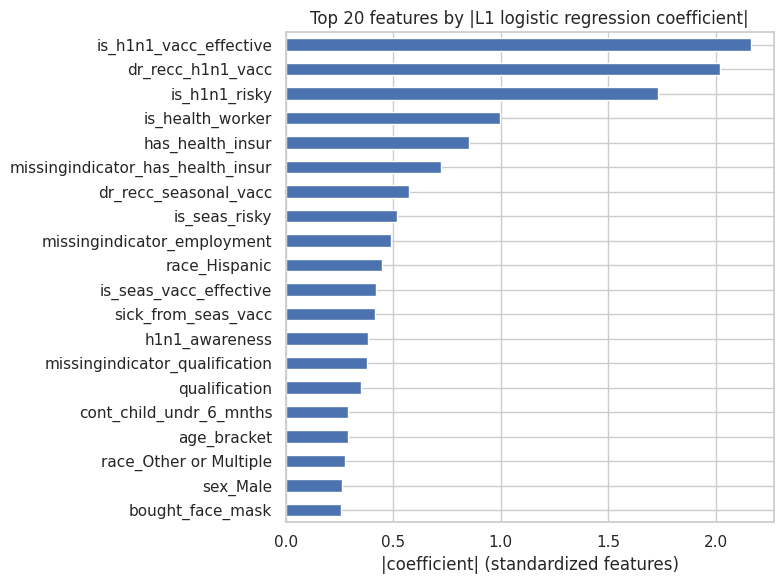

In [ ]:
plt.figure(figsize=(8, 6))
coef_importance.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 features by |L1 logistic regression coefficient|")
plt.xlabel("|coefficient| (standardized features)")
plt.tight_layout()
plt.show()

In [ ]:
for k in [5, 10, 15, 20, 30]:
    cols = coef_importance.head(k).index.tolist()
    results = classification_eval(
        f"min_max_scaled_balanced_top{k}",
        LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
        X_train_mm[cols], y_train, fold=5
    )

results[results["method"].str.startswith("min_max_scaled_balanced_top")]

,method,mean_train_acc,mean_valid_acc,std_train_acc,std_valid_acc,mean_train_precision,mean_valid_precision,std_train_precision,std_valid_precision,mean_train_recall,mean_valid_recall,std_train_recall,std_valid_recall,mean_train_f1,mean_valid_f1,std_train_f1,std_valid_f1
6,min_max_scaled_balanced_top5,0.792911,0.792312,0.002380,0.003928,0.508552,0.507731,0.003897,0.006384,0.751704,0.750176,0.004165,0.023201,0.606649,0.605368,0.001945,0.006826
7,min_max_scaled_balanced_top10,0.791825,0.791563,0.001403,0.006595,0.506714,0.506544,0.002217,0.010469,0.756345,0.755347,0.003145,0.016441,0.606860,0.606270,0.002475,0.008795
8,min_max_scaled_balanced_top15,0.792886,0.793110,0.001427,0.005308,0.508384,0.508875,0.002276,0.008379,0.759459,0.759342,0.002064,0.015111,0.609059,0.609279,0.002069,0.007908
9,min_max_scaled_balanced_top20,0.795195,0.795107,0.001300,0.006656,0.512007,0.512036,0.002059,0.010577,0.765511,0.764982,0.002808,0.013824,0.613607,0.613379,0.002297,0.009939
10,min_max_scaled_balanced_top30,0.796942,0.796256,0.001081,0.002667,0.514807,0.513726,0.001722,0.004248,0.767156,0.766157,0.002179,0.013001,0.616144,0.615006,0.001844,0.005821


## 8. Polynomial / interaction features

Full-degree-2 polynomial features across *all* ~50+ columns would explode the
dimensionality and mostly add noise. Instead, apply `PolynomialFeatures` only to
the top-K important columns found above, then evaluate.

> Set `BEST_K` to whichever top-K performed best in Section 7.

In [ ]:
BEST_K = 5  # <-- update based on the Section 7 results table
important_cols = coef_importance.head(BEST_K).index.tolist()
important_cols

['is_h1n1_vacc_effective',
 'dr_recc_h1n1_vacc',
 'is_h1n1_risky',
 'is_health_worker',
 'has_health_insur']

In [ ]:
poly = PolynomialFeatures(degree=5, interaction_only=False, include_bias=False)
X_train_poly = poly.fit_transform(X_train_mm[important_cols])
X_train_poly = pd.DataFrame(
    X_train_poly, columns=poly.get_feature_names_out(important_cols), index=X_train_mm.index
)
print("Feature count:", X_train_poly.shape[1])

results = classification_eval(
    f"min_max_scaled_balanced_top{BEST_K}_poly5",
    LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    X_train_poly, y_train, fold=5
)
results

Feature count: 251


,method,mean_train_acc,mean_valid_acc,std_train_acc,std_valid_acc,mean_train_precision,mean_valid_precision,std_train_precision,std_valid_precision,mean_train_recall,mean_valid_recall,std_train_recall,std_valid_recall,mean_train_f1,mean_valid_f1,std_train_f1,std_valid_f1
0,baseline_raw,0.853520,0.851922,0.000804,0.002173,0.729620,0.723320,0.001571,0.009208,0.493243,0.490952,0.005216,0.016221,0.588571,0.584680,0.003820,0.010713
1,standard_scaled,0.853532,0.851672,0.000819,0.002513,0.729203,0.722153,0.001443,0.008952,0.493948,0.490717,0.005111,0.016578,0.588938,0.584151,0.003806,0.011602
2,minmax_scaled,0.853507,0.851722,0.000647,0.002632,0.729800,0.722854,0.001287,0.009144,0.492891,0.490012,0.004850,0.016734,0.588378,0.583882,0.003395,0.011902
3,raw_balanced,0.796181,0.794958,0.001039,0.002691,0.513568,0.511713,0.001631,0.004338,0.767215,0.762867,0.003409,0.013030,0.615274,0.612485,0.002161,0.004878
4,standard_scaled_balanced,0.796131,0.794658,0.001170,0.002836,0.513486,0.511241,0.001844,0.004577,0.767333,0.762632,0.003406,0.012808,0.615253,0.612069,0.002298,0.004788
5,minmax_scaled_balanced,0.796243,0.795207,0.001207,0.002809,0.513670,0.512120,0.001909,0.004550,0.767274,0.763102,0.003106,0.011718,0.615366,0.612857,0.002252,0.004463
6,min_max_scaled_balanced_top5,0.792911,0.792312,0.002380,0.003928,0.508552,0.507731,0.003897,0.006384,0.751704,0.750176,0.004165,0.023201,0.606649,0.605368,0.001945,0.006826
7,min_max_scaled_balanced_top10,0.791825,0.791563,0.001403,0.006595,0.506714,0.506544,0.002217,0.010469,0.756345,0.755347,0.003145,0.016441,0.606860,0.606270,0.002475,0.008795
8,min_max_scaled_balanced_top15,0.792886,0.793110,0.001427,0.005308,0.508384,0.508875,0.002276,0.008379,0.759459,0.759342,0.002064,0.015111,0.609059,0.609279,0.002069,0.007908
9,min_max_scaled_balanced_top20,0.795195,0.795107,0.001300,0.006656,0.512007,0.512036,0.002059,0.010577,0.765511,0.764982,0.002808,0.013824,0.613607,0.613379,0.002297,0.009939


In [ ]:
results.sort_values(by = "mean_valid_f1", ascending = False)

,method,mean_train_acc,mean_valid_acc,std_train_acc,std_valid_acc,mean_train_precision,mean_valid_precision,std_train_precision,std_valid_precision,mean_train_recall,mean_valid_recall,std_train_recall,std_valid_recall,mean_train_f1,mean_valid_f1,std_train_f1,std_valid_f1
10,min_max_scaled_balanced_top30,0.796942,0.796256,0.001081,0.002667,0.514807,0.513726,0.001722,0.004248,0.767156,0.766157,0.002179,0.013001,0.616144,0.615006,0.001844,0.005821
9,min_max_scaled_balanced_top20,0.795195,0.795107,0.001300,0.006656,0.512007,0.512036,0.002059,0.010577,0.765511,0.764982,0.002808,0.013824,0.613607,0.613379,0.002297,0.009939
5,minmax_scaled_balanced,0.796243,0.795207,0.001207,0.002809,0.513670,0.512120,0.001909,0.004550,0.767274,0.763102,0.003106,0.011718,0.615366,0.612857,0.002252,0.004463
3,raw_balanced,0.796181,0.794958,0.001039,0.002691,0.513568,0.511713,0.001631,0.004338,0.767215,0.762867,0.003409,0.013030,0.615274,0.612485,0.002161,0.004878
4,standard_scaled_balanced,0.796131,0.794658,0.001170,0.002836,0.513486,0.511241,0.001844,0.004577,0.767333,0.762632,0.003406,0.012808,0.615253,0.612069,0.002298,0.004788
13,min_max_scaled_balanced_top5_poly4,0.797029,0.796405,0.001904,0.005311,0.515244,0.514288,0.003136,0.008617,0.753349,0.752056,0.005371,0.021921,0.611941,0.610726,0.003087,0.010929
11,min_max_scaled_balanced_top5_poly2,0.796518,0.796306,0.001331,0.004932,0.514381,0.514142,0.002153,0.008055,0.753584,0.752291,0.005032,0.018983,0.611414,0.610714,0.002634,0.009289
12,min_max_scaled_balanced_top5_poly3,0.796830,0.796056,0.001834,0.005015,0.514892,0.513695,0.002987,0.008132,0.753995,0.752761,0.004031,0.022914,0.611913,0.610525,0.003140,0.010754
14,min_max_scaled_balanced_top5_poly5,0.796518,0.795507,0.001642,0.005383,0.514359,0.512755,0.002744,0.008669,0.755582,0.752761,0.006558,0.021675,0.612042,0.609901,0.002528,0.011485
8,min_max_scaled_balanced_top15,0.792886,0.793110,0.001427,0.005308,0.508384,0.508875,0.002276,0.008379,0.759459,0.759342,0.002064,0.015111,0.609059,0.609279,0.002069,0.007908


## 9. Compare every experiment

Rank all configurations by mean validation F1. Also check the gap between train
and validation F1 as a quick overfitting signal — a config with a much higher
train F1 than valid F1 is memorizing, not generalizing.

In [ ]:
results["overfit_gap"] = results["mean_train_f1"] - results["mean_valid_f1"]
results_sorted = results.sort_values("mean_valid_f1", ascending=False).reset_index(drop=True)
results_sorted

,method,mean_train_acc,mean_valid_acc,std_train_acc,std_valid_acc,mean_train_precision,mean_valid_precision,std_train_precision,std_valid_precision,mean_train_recall,mean_valid_recall,std_train_recall,std_valid_recall,mean_train_f1,mean_valid_f1,std_train_f1,std_valid_f1,overfit_gap
0,"random_forest max_depth = 8, balanced",0.828183,0.808088,0.001835,0.005996,0.570046,0.535553,0.003923,0.010901,0.778378,0.731610,0.004043,0.014074,0.658097,0.618301,0.001676,0.009120,0.039796
1,min_max_scaled_balanced_top30,0.796942,0.796256,0.001081,0.002667,0.514807,0.513726,0.001722,0.004248,0.767156,0.766157,0.002179,0.013001,0.616144,0.615006,0.001844,0.005821,0.001138
2,min_max_scaled_balanced_top20,0.795195,0.795107,0.001300,0.006656,0.512007,0.512036,0.002059,0.010577,0.765511,0.764982,0.002808,0.013824,0.613607,0.613379,0.002297,0.009939,0.000228
3,minmax_scaled_balanced,0.796243,0.795207,0.001207,0.002809,0.513670,0.512120,0.001909,0.004550,0.767274,0.763102,0.003106,0.011718,0.615366,0.612857,0.002252,0.004463,0.002509
4,raw_balanced,0.796181,0.794958,0.001039,0.002691,0.513568,0.511713,0.001631,0.004338,0.767215,0.762867,0.003409,0.013030,0.615274,0.612485,0.002161,0.004878,0.002790
5,standard_scaled_balanced,0.796131,0.794658,0.001170,0.002836,0.513486,0.511241,0.001844,0.004577,0.767333,0.762632,0.003406,0.012808,0.615253,0.612069,0.002298,0.004788,0.003184
6,min_max_scaled_top5_gridsearch_weight2.5,0.823090,0.823065,0.001354,0.003714,0.573112,0.573001,0.002835,0.007072,0.655405,0.655464,0.004167,0.018837,0.611499,0.611383,0.003092,0.011256,0.000115
7,min_max_scaled_balanced_top5_poly4,0.797029,0.796405,0.001904,0.005311,0.515244,0.514288,0.003136,0.008617,0.753349,0.752056,0.005371,0.021921,0.611941,0.610726,0.003087,0.010929,0.001215
8,min_max_scaled_balanced_top5_poly2,0.796518,0.796306,0.001331,0.004932,0.514381,0.514142,0.002153,0.008055,0.753584,0.752291,0.005032,0.018983,0.611414,0.610714,0.002634,0.009289,0.000700
9,min_max_scaled_balanced_top5_poly3,0.796830,0.796056,0.001834,0.005015,0.514892,0.513695,0.002987,0.008132,0.753995,0.752761,0.004031,0.022914,0.611913,0.610525,0.003140,0.010754,0.001388


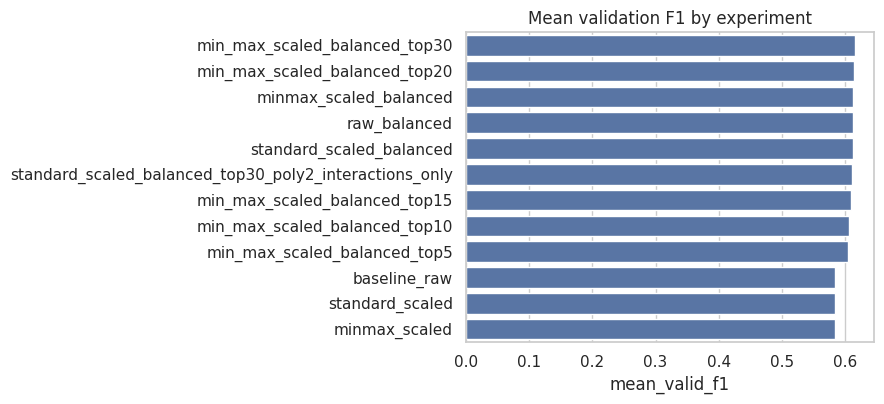

In [ ]:
plt.figure(figsize=(9, max(4, 0.35 * len(results_sorted))))
sns.barplot(data=results_sorted, y="method", x="mean_valid_f1", color="#4C72B0")
plt.title("Mean validation F1 by experiment")
plt.xlabel("mean_valid_f1")
plt.ylabel("")
plt.tight_layout()
plt.show()

results_sorted.to_csv("model_experiment_results.csv", index=False)

## 10. Final model — refit best config, evaluate on the held-out test set

Update `FINAL_*` below to match whichever row wins in `results_sorted`. As
written, this assumes standardized features + `class_weight="balanced"` +
the top-K important columns from Section 7 (no polynomial features — add that
step here too if it wins).

In [ ]:
important_cols

['is_h1n1_vacc_effective',
 'dr_recc_h1n1_vacc',
 'is_h1n1_risky',
 'is_health_worker',
 'has_health_insur']

In [ ]:
model = LogisticRegression(max_iter = 2000, class_weight="balanced")
mm_scaler = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train[important_cols])
X_test_mm = mm_scaler.transform(X_test[important_cols])
poly = PolynomialFeatures(degree = 2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_mm)
X_test_poly = poly.transform(X_test_mm)

model.fit(X_train_poly, y_train)
y_pred_train = model.predict(X_train_poly)
y_pred_test = model.predict(X_test_poly)

In [ ]:
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       0.92      0.81      0.86     15775
           1       0.51      0.75      0.61      4255

    accuracy                           0.80     20030
   macro avg       0.72      0.78      0.74     20030
weighted avg       0.84      0.80      0.81     20030



In [ ]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.92      0.80      0.85      5258
           1       0.50      0.73      0.59      1419

    accuracy                           0.79      6677
   macro avg       0.71      0.77      0.72      6677
weighted avg       0.83      0.79      0.80      6677



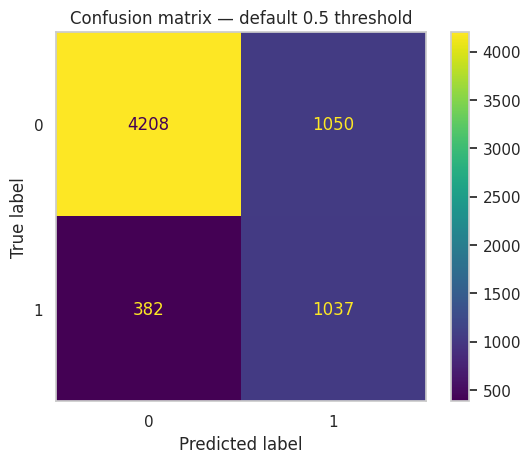

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
plt.title("Confusion matrix — default 0.5 threshold")
plt.grid(False)
plt.show()

In [ ]:
y_pred_prob_train = model.predict_proba(X_train_poly)[:,1]
y_pred_prob_test = model.predict_proba(X_test_poly)[:,1]

In [ ]:
p, r, t = precision_recall_curve(y_train, y_pred_prob_train)

In [ ]:
f1 = 2*p*r/(p+r)
f1.max()
idx = f1.argmax()
idx

np.int64(107)

Text(0.5, 1.0, 'for threshold0.5856989888863433')

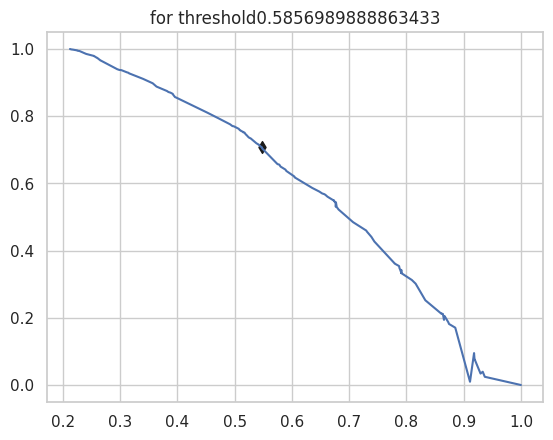

In [ ]:
sns.lineplot(x = p, y = r)
plt.scatter(x = p[107], y = r[107], marker = "d", color = "k")
plt.title(f"for threshold{t[107]}")

In [ ]:
best_thresh = t[107]
y_train_pred_bt =np.where(y_pred_prob_train >= best_thresh, 1, 0)
y_test_pred_bt =np.where(y_pred_prob_test >= best_thresh, 1, 0)

In [ ]:
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       0.92      0.81      0.86     15775
           1       0.51      0.75      0.61      4255

    accuracy                           0.80     20030
   macro avg       0.72      0.78      0.74     20030
weighted avg       0.84      0.80      0.81     20030



In [ ]:
print(classification_report(y_train, y_train_pred_bt))

              precision    recall  f1-score   support

           0       0.91      0.84      0.88     15775
           1       0.55      0.71      0.62      4255

    accuracy                           0.81     20030
   macro avg       0.73      0.77      0.75     20030
weighted avg       0.84      0.81      0.82     20030



In [ ]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.92      0.80      0.85      5258
           1       0.50      0.73      0.59      1419

    accuracy                           0.79      6677
   macro avg       0.71      0.77      0.72      6677
weighted avg       0.83      0.79      0.80      6677



In [ ]:
print(classification_report(y_test, y_test_pred_bt))

              precision    recall  f1-score   support

           0       0.91      0.83      0.87      5258
           1       0.52      0.68      0.59      1419

    accuracy                           0.80      6677
   macro avg       0.72      0.76      0.73      6677
weighted avg       0.83      0.80      0.81      6677



              precision    recall  f1-score   support

           0      0.921     0.789     0.850      5258
           1      0.489     0.749     0.592      1419

    accuracy                          0.780      6677
   macro avg      0.705     0.769     0.721      6677
weighted avg      0.829     0.780     0.795      6677

Test F1: 0.5915


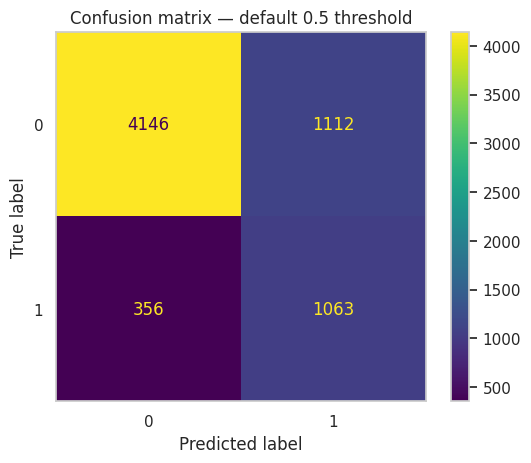

In [ ]:
FINAL_COLS = important_cols  # or X_train.columns.tolist() for all features

# reuse scaler_std, which was already fit on X_train — transform test consistently
X_test_mm = pd.DataFrame(
    scaler_mm.transform(X_test[X_train.columns]), columns=X_train.columns, index=X_test.index
)

X_train_final = X_train_mm[FINAL_COLS]
X_test_final = X_test_mm[FINAL_COLS]

final_model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
final_model.fit(X_train_final, y_train)

y_test_pred = final_model.predict(X_test_final)
print(classification_report(y_test, y_test_pred, digits=3))
print("Test F1:", round(f1_score(y_test, y_test_pred), 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
plt.title("Confusion matrix — default 0.5 threshold")
plt.grid(False)
plt.show()

## 11. Threshold tuning for F1

Logistic Regression's default 0.5 decision threshold is not necessarily
F1-optimal on an imbalanced target. Use out-of-fold predicted probabilities on
the training set (via `cross_val_predict`, so it's unbiased) to find the
threshold that maximizes F1, then apply that threshold — not 0.5 — to the test
set.

Best CV threshold: 0.608  |  Best CV F1: 0.6322


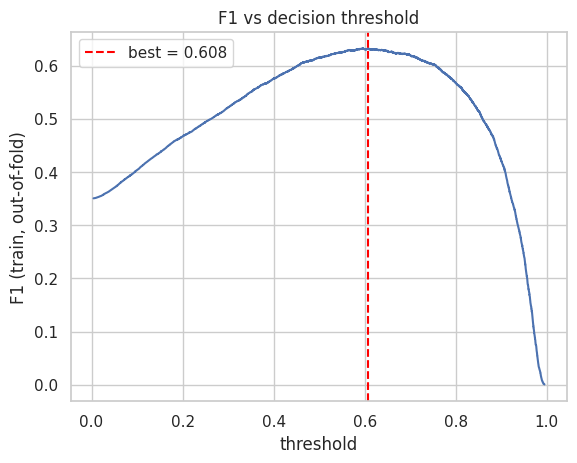

In [ ]:
y_train_proba = cross_val_predict(
    final_model, X_train_final, y_train, cv=5, method="predict_proba"
)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, y_train_proba)
f1_curve = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_curve[:-1])  # last point has no matching threshold
best_threshold = thresholds[best_idx]

print(f"Best CV threshold: {best_threshold:.3f}  |  Best CV F1: {f1_curve[best_idx]:.4f}")

plt.plot(thresholds, f1_curve[:-1])
plt.axvline(best_threshold, color="red", linestyle="--", label=f"best = {best_threshold:.3f}")
plt.xlabel("threshold")
plt.ylabel("F1 (train, out-of-fold)")
plt.title("F1 vs decision threshold")
plt.legend()
plt.show()

              precision    recall  f1-score   support

           0      0.904     0.861     0.882      5258
           1      0.563     0.662     0.608      1419

    accuracy                          0.819      6677
   macro avg      0.734     0.762     0.745      6677
weighted avg      0.832     0.819     0.824      6677

Tuned-threshold test F1: 0.6084


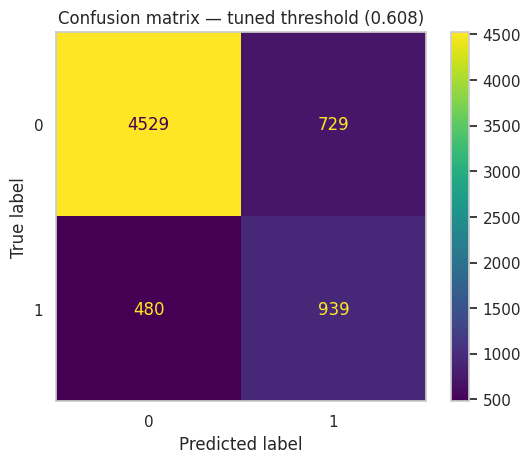

In [ ]:
y_test_proba = final_model.predict_proba(X_test_final)[:, 1]
y_test_pred_tuned = (y_test_proba >= best_threshold).astype(int)

print(classification_report(y_test, y_test_pred_tuned, digits=3))
print("Tuned-threshold test F1:", round(f1_score(y_test, y_test_pred_tuned), 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_tuned)
plt.grid(False)
plt.title(f"Confusion matrix — tuned threshold ({best_threshold:.3f})")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

X_grid = X_train_mm[important_cols]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grid = [
    {
        "penalty": ["l2"],
        "solver": ["lbfgs"],
        "C": [0.001, 0.01, 0.1, 0.3, 1, 3, 10, 30, 100],
        "class_weight": ["balanced"],
    },
    {
        "penalty": ["l1"],
        "solver": ["liblinear"],
        "C": [0.001, 0.01, 0.1, 0.3, 1, 3, 10, 30, 100],
        "class_weight": ["balanced"],
    },
]

c_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True,
)
c_grid.fit(X_grid, y_train)

print("Best CV F1:", round(c_grid.best_score_, 4))
print("Best params:", c_grid.best_params_)

c_grid_results = pd.DataFrame(c_grid.cv_results_).sort_values("rank_test_score")
c_grid_results[["param_penalty", "param_C", "mean_test_score", "std_test_score", "rank_test_score"]].head(10)

Best CV F1: 0.6061
Best params: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}


,param_penalty,param_C,mean_test_score,std_test_score,rank_test_score
13,l1,1.0,0.606058,0.008088,1
12,l1,0.3,0.605998,0.008051,2
4,l2,1.0,0.605914,0.008343,3
3,l2,0.3,0.605855,0.008307,4
14,l1,3.0,0.605781,0.008094,5
15,l1,10.0,0.605781,0.008094,5
17,l1,100.0,0.605781,0.008094,5
16,l1,30.0,0.605781,0.008094,5
8,l2,100.0,0.605637,0.008344,9
7,l2,30.0,0.605637,0.008344,9


In [ ]:
results = classification_eval(
    f"min_max_scaled_balanced_top{BEST_K}_gridsearch_C{c_grid.best_params_['C']}_{c_grid.best_params_['penalty']}",
    c_grid.best_estimator_,
    X_grid, y_train, fold=5
)
results.tail(1)

,method,mean_train_acc,mean_valid_acc,std_train_acc,std_valid_acc,mean_train_precision,mean_valid_precision,std_train_precision,std_valid_precision,mean_train_recall,mean_valid_recall,std_train_recall,std_valid_recall,mean_train_f1,mean_valid_f1,std_train_f1,std_valid_f1
15,min_max_scaled_balanced_top5_gridsearch_C1_l1,0.792973,0.792411,0.002317,0.003817,0.508653,0.507892,0.003798,0.006215,0.751528,0.749941,0.004202,0.023044,0.606664,0.605408,0.001922,0.006663


In [ ]:
best_C = c_grid.best_params_["C"]
best_penalty = c_grid.best_params_["penalty"]
best_solver = c_grid.best_params_["solver"]

weight_grid = [1, 1.5, 2, 2.5, 3, 3.7, 4.5, 6]  # 3.7 ≈ "balanced" for this class split

cw_param_grid = {
    "C": [best_C],
    "penalty": [best_penalty],
    "solver": [best_solver],
    "class_weight": [{0: 1, 1: w} for w in weight_grid],
}

cw_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    param_grid=cw_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True,
)
cw_grid.fit(X_grid, y_train)

print("Best CV F1:", round(cw_grid.best_score_, 4))
print("Best class_weight ratio:", cw_grid.best_params_["class_weight"])

cw_grid_results = pd.DataFrame(cw_grid.cv_results_).sort_values("rank_test_score")
cw_grid_results[["param_class_weight", "mean_test_score", "std_test_score", "rank_test_score"]]

Best CV F1: 0.6115
Best class_weight ratio: {0: 1, 1: 2.5}


,param_class_weight,mean_test_score,std_test_score,rank_test_score
3,"{0: 1, 1: 2.5}",0.611545,0.008622,1
2,"{0: 1, 1: 2}",0.610711,0.005845,2
4,"{0: 1, 1: 3}",0.607755,0.006815,3
5,"{0: 1, 1: 3.7}",0.605781,0.008094,4
1,"{0: 1, 1: 1.5}",0.602795,0.007566,5
6,"{0: 1, 1: 4.5}",0.593777,0.009710,6
0,"{0: 1, 1: 1}",0.550909,0.015989,7
7,"{0: 1, 1: 6}",0.540011,0.004644,8


In [ ]:
results = classification_eval(
    f"min_max_scaled_top{BEST_K}_gridsearch_weight{cw_grid.best_params_['class_weight'][1]}",
    cw_grid.best_estimator_,
    X_grid, y_train, fold=5
)
results.tail(1)

,method,mean_train_acc,mean_valid_acc,std_train_acc,std_valid_acc,mean_train_precision,mean_valid_precision,std_train_precision,std_valid_precision,mean_train_recall,mean_valid_recall,std_train_recall,std_valid_recall,mean_train_f1,mean_valid_f1,std_train_f1,std_valid_f1
16,min_max_scaled_top5_gridsearch_weight2.5,0.82309,0.823065,0.001354,0.003714,0.573112,0.573001,0.002835,0.007072,0.655405,0.655464,0.004167,0.018837,0.611499,0.611383,0.003092,0.011256


In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state = 42)
results = classification_eval(
    f"random_forest",
    model,
    X_train, y_train, fold=5
)
results.tail(1)

,method,mean_train_acc,mean_valid_acc,std_train_acc,std_valid_acc,mean_train_precision,mean_valid_precision,std_train_precision,std_valid_precision,mean_train_recall,mean_valid_recall,std_train_recall,std_valid_recall,mean_train_f1,mean_valid_f1,std_train_f1,std_valid_f1
17,random_forest,0.99995,0.85312,0.000025,0.004052,1.0,0.756505,0.0,0.014166,0.999765,0.455229,0.000118,0.020631,0.999882,0.568133,0.000059,0.016921


In [ ]:
model = RandomForestClassifier(max_depth = 8,random_state = 42, class_weight = "balanced")
results = classification_eval(
    f"random_forest max_depth = 8, balanced",
    model,
    X_train, y_train, fold=5
)
results.tail(1)

,method,mean_train_acc,mean_valid_acc,std_train_acc,std_valid_acc,mean_train_precision,mean_valid_precision,std_train_precision,std_valid_precision,mean_train_recall,mean_valid_recall,std_train_recall,std_valid_recall,mean_train_f1,mean_valid_f1,std_train_f1,std_valid_f1
19,"random_forest max_depth = 8, balanced",0.828183,0.808088,0.001835,0.005996,0.570046,0.535553,0.003923,0.010901,0.778378,0.73161,0.004043,0.014074,0.658097,0.618301,0.001676,0.00912


## 12. Summary

Fill this in once the notebook has actually run against your data:

- **Best experiment (by CV valid F1):** _fill in from `results_sorted.iloc[0]`_
- **Winning config:** scaler / class_weight / feature subset / poly features
- **Held-out test F1 (default threshold):** _fill in_
- **Held-out test F1 (tuned threshold):** _fill in_
- **Chosen decision threshold:** `best_threshold`

Full experiment log saved to `model_experiment_results.csv`.